In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from numpy import exp

# ===============================
# Excel-Datei laden
# ===============================
df = pd.read_excel("Exp1_Elchem Messtechnik_Template 2025.xlsx", engine="openpyxl",
                   usecols="B,C", skiprows=31, nrows=6)
df.columns = ["c", "E"]

In [9]:
print(df.round(4))

        c       E
0  1.0000  0.2276
1  0.2236  0.2268
2  0.1000  0.2223
3  0.0707  0.2209
4  0.0316  0.2156
5  0.0224  0.2152


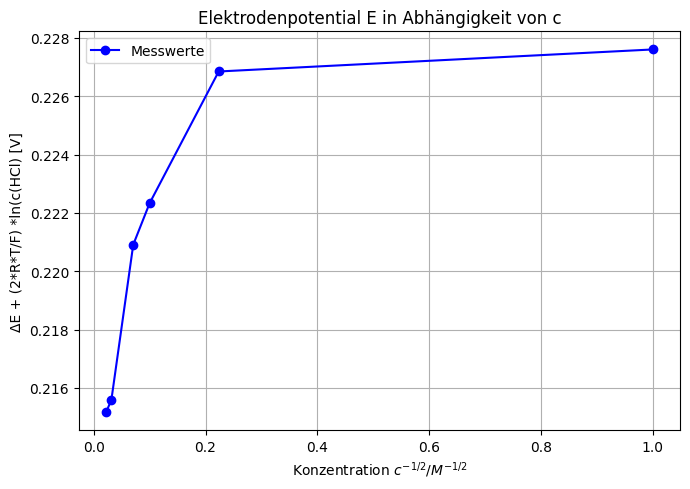

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from numpy import log

# ===============================
# Excel-Datei laden
# ===============================
df = pd.read_excel("Exp1_Elchem Messtechnik_Template 2025.xlsx", engine="openpyxl",
                   usecols="B,C", skiprows=31, nrows=6)
df.columns = ["c", "E"]

# ===============================
# Plot erstellen
# ===============================
plt.figure(figsize=(7, 5))

# Punkte zeichnen
plt.plot(df["c"], df["E"], marker='o', linestyle='-', color='blue', label='Messwerte')

# Achsen und Titel
plt.xlabel(r"Konzentration $c^{-1/2} / M^{-1/2}$")
plt.ylabel("ΔE + (2*R*T/F) *ln(c(HCl) [V]")
plt.title("Elektrodenpotential E in Abhängigkeit von c")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

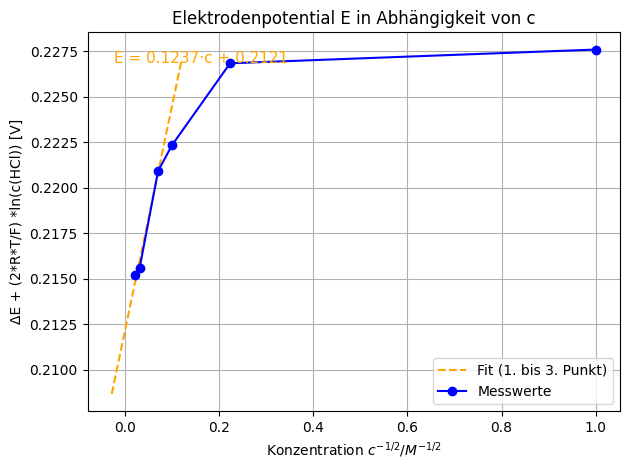

In [49]:
# ===============================
# Lineare Regression für die ersten 3 Punkte
# ===============================
x_fit = df["c"].iloc[-3:]
y_fit = df["E"].iloc[-3:]

# Lineare Regression: Grad 1
coeffs = np.polyfit(x_fit, y_fit, deg=1)
poly = np.poly1d(coeffs)

plt.text(0.05, 0.95, f"E = {m:.4f}·c + {b:.4f}",
         transform=plt.gca().transAxes,
         fontsize=11, color='orange',
         verticalalignment='top')

# Fit-Kurve zeichnen
x_start = x_fit.min() - 0.05
x_end = x_fit.max() + 0.05
x_line = np.linspace(x_start, x_end, 100)
y_line = poly(x_line)

# Gerade zum Plot hinzufügen
plt.plot(x_line, y_line, color='orange', linestyle='--', label="Fit (1. bis 3. Punkt)")

# ===============================
# Originalplot wiederholen
# ===============================
plt.plot(df["c"], df["E"], marker='o', linestyle='-', color='blue', label='Messwerte')

# Achsen und Titel
plt.xlabel(r"Konzentration $c^{-1/2} / M^{-1/2}$")
plt.ylabel("ΔE + (2*R*T/F) *ln(c(HCl)) [V]")
plt.title("Elektrodenpotential E in Abhängigkeit von c")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

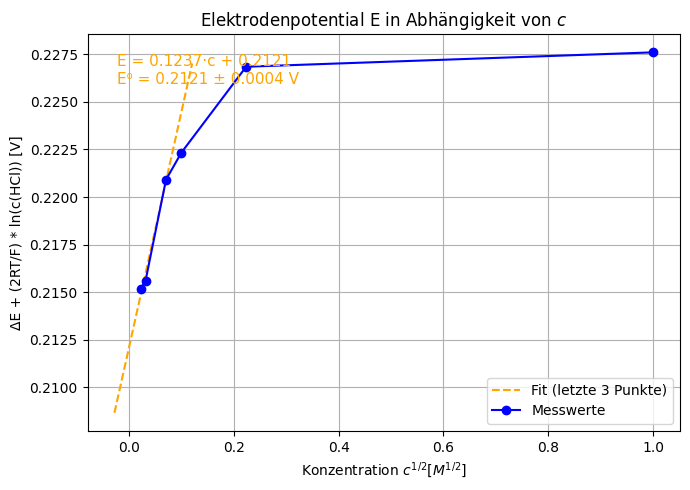

E⁰ (y-Achsenabschnitt): 0.2121 ± 0.0004 V
Steigung: 0.1237 V · M^½


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Excel-Datei laden
# ===============================
df = pd.read_excel("Exp1_Elchem Messtechnik_Template 2025.xlsx", engine="openpyxl",
                   usecols="B,C", skiprows=31, nrows=6)
df.columns = ["c", "E"]

# ===============================
# Lineare Regression für die letzten 3 Punkte
# ===============================
x_fit = df["c"].iloc[-3:]
y_fit = df["E"].iloc[-3:]

# Polyfit (Grad 1)
coeffs = np.polyfit(x_fit, y_fit, deg=1)
poly = np.poly1d(coeffs)
m, b = coeffs  # Steigung, y-Achsenabschnitt

# Fehlerberechnung für den y-Intercept (E^0)
n = len(x_fit)
x_mean = np.mean(x_fit)
s_xx = np.sum((x_fit - x_mean)**2)
y_pred = poly(x_fit)
residuals = y_fit - y_pred
std_err = np.sqrt(np.sum(residuals**2) / (n - 2)) / np.sqrt(n)
b_err = std_err * np.sqrt(1/n + x_mean**2 / s_xx)

# ===============================
# Fit-Kurve vorbereiten
# ===============================
x_start = x_fit.min() - 0.05
x_end = x_fit.max() + 0.05
x_line = np.linspace(x_start, x_end, 100)
y_line = poly(x_line)

# ===============================
# Plot erstellen
# ===============================
plt.figure(figsize=(7, 5))

# Fit-Kurve
plt.plot(x_line, y_line, color='orange', linestyle='--', label="Fit (letzte 3 Punkte)")

# Fit-Formel einblenden
plt.text(0.05, 0.95,
         f"E = {m:.4f}·c + {b:.4f}\nE⁰ = {b:.4f} ± {b_err:.4f} V",
         transform=plt.gca().transAxes,
         fontsize=11, color='orange',
         verticalalignment='top')

# Originaldaten
plt.plot(df["c"], df["E"], marker='o', linestyle='-', color='blue', label='Messwerte')

# Layout
plt.xlabel(r"Konzentration $c^{1/2} [M^{1/2}$]")
plt.ylabel("ΔE + (2RT/F) * ln(c(HCl)) [V]")
plt.title("Elektrodenpotential E in Abhängigkeit von $c$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# Terminalausgabe
# ===============================
print(f"E⁰ (y-Achsenabschnitt): {b:.4f} ± {b_err:.4f} V")
print(f"Steigung: {m:.4f} V · M^½")